### Measuring lexical diversity
- Using MATTR (Moving Average Type Token Ratio) with window size of 100. This allows for measuring of lexical diversity regardless of span lengths. 
- distinct_2: bigram level diversity to check for common phrases. How repetitive are real vs synth samples on the phrase level?


In [8]:
import json
import re
from collections import Counter

def tokenize(text: str):
    return re.findall(r"\b\w+\b", str(text).lower())

def type_token_ratio(tokens):
    return (len(set(tokens)) / len(tokens)) if tokens else 0.0

def moving_average_ttr(tokens, window_size=100):
    if len(tokens) < window_size:
        return type_token_ratio(tokens)
    ttrs = []
    for i in range(len(tokens) - window_size + 1):
        window = tokens[i:i+window_size]
        ttrs.append(type_token_ratio(window))
    return sum(ttrs) / len(ttrs) if ttrs else 0.0

def distinct_n(tokens, n=1):
    if len(tokens) < n:
        return 0.0
    ngrams = list(zip(*[tokens[i:] for i in range(n)]))
    return (len(set(ngrams)) / len(ngrams)) if ngrams else 0.0

def lexical_stats(texts):
    all_tokens = []
    span_lengths = []

    for text in texts:
        toks = tokenize(text)
        all_tokens.extend(toks)
        span_lengths.append(len(toks))

    vocab = set(all_tokens)
    freq = Counter(all_tokens)

    num_spans = len(texts)
    total_tokens = len(all_tokens)

    return {
        "num_spans": num_spans,
        "total_tokens": total_tokens,
        "tokens_per_span": (total_tokens / num_spans) if num_spans else 0.0,
        "vocab_size": len(vocab),
        "vocab_per_span": (len(vocab) / num_spans) if num_spans else 0.0,
        "avg_span_length": (sum(span_lengths) / num_spans) if num_spans else 0.0,
        "mattr_100": moving_average_ttr(all_tokens, window_size=100),
        "distinct_2": distinct_n(all_tokens, n=2),
        "top_20_token_coverage": (
            sum(freq[w] for w, _ in freq.most_common(20)) / total_tokens
            if total_tokens else 0.0
        ),
    }

def _fmt(v):
    return f"{v:.4f}" if isinstance(v, float) else str(v)

CATEGORIES = ["Unsupported claim", "Lacks synthesis", "Format", "Coherence"]

def load_by_cat(data):
    """
    Accept an already-loaded dict and return a dict mapping category -> list of span strings.
    """
    by_cat = {cat: [] for cat in CATEGORIES}

    for cat, entries in data.items():
        if cat not in by_cat:
            continue
        for entry in entries:
            for span_obj in entry.get("spans", []):
                span_text = span_obj.get("span", "")
                if span_text:
                    by_cat[cat].append(span_text)

    return by_cat

    
def compare_datasets(synth_path, real_path):
    synth_by_cat = load_by_cat(synth_path)
    real_by_cat = load_by_cat(real_path)

    cats = sorted(set(synth_by_cat.keys()) | set(real_by_cat.keys()))
    results = {}

    for cat in cats:
        synth_texts = synth_by_cat.get(cat, [])
        real_texts = real_by_cat.get(cat, [])

        synth_stats = lexical_stats(synth_texts)
        real_stats = lexical_stats(real_texts)

        results[cat] = {
            "synthetic": synth_stats if synth_stats["num_spans"] > 0 else None,
            "real": real_stats if real_stats["num_spans"] > 0 else None,
        }

    return results

In [9]:
import json 

synth_path = "../samples/synthetic_samples_complete.json"
real_path = "../samples/total_real_data.json"

with open(synth_path, 'r') as f:
    synth_data = json.load(f)

with open(real_path, 'r') as f:
    real_data = json.load(f)
     
results = compare_datasets(synth_data, real_data)

# save results into json file
with open("results/comparison_results.json", "w") as f:
    json.dump(results, f, indent=2)

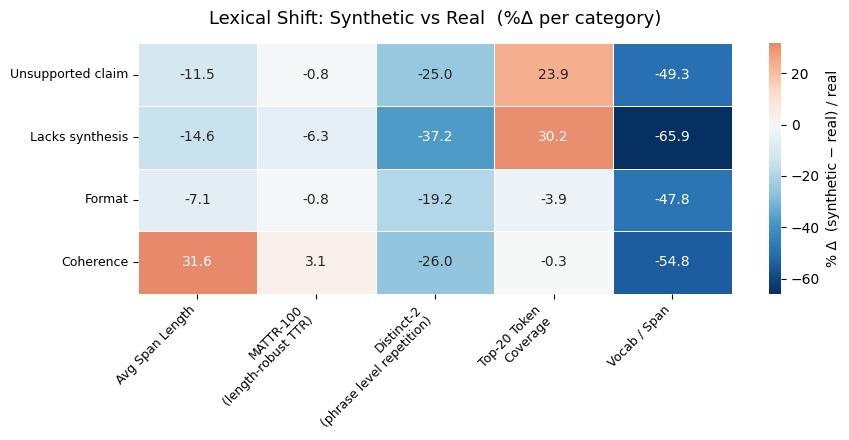

** Saved to heatmap_relative_shift.png **


In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open("results/comparison_results.json", "r") as f:
    results = json.load(f)

CATEGORIES = ["Unsupported claim", "Lacks synthesis", "Format", "Coherence"]

METRICS = {
    "avg_span_length": "Avg Span Length",
    "mattr_100": "MATTR-100\n(length-robust TTR)",
    "distinct_2": "Distinct-2\n(phrase level repetition)",
    "top_20_token_coverage": "Top-20 Token\nCoverage",
    "vocab_per_span": "Vocab / Span",
}

matrix = []
for cat in CATEGORIES:
    row = []
    cat_data = results.get(cat, {})
    synth = cat_data["synthetic"] 
    real  = cat_data["real"] 
    for metric in METRICS:
        s = synth[metric]
        r = real[metric]
        if s is None or r is None or r == 0:
            row.append(np.nan)
        else:
            row.append((s - r) / r * 100)  # % delta or relative difference b/w synth and real
    matrix.append(row)

matrix = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.heatmap(
    matrix,
    ax=ax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="RdBu_r",
    center=0,
    xticklabels=list(METRICS.values()),
    yticklabels=CATEGORIES,
    cbar_kws={"label": "% Δ  (synthetic − real) / real"},
)

ax.set_title("Lexical Shift: Synthetic vs Real  (%Δ per category)", fontsize=13, pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.tight_layout()
plt.savefig("results/heatmap_relative_shift.png", dpi=150)
plt.show()
print("** Saved to heatmap_relative_shift.png **")

In [10]:
import json
import re
from collections import Counter

def tokenize(text: str):
    return re.findall(r"\b\w+\b", str(text).lower())

def count_sentences(text: str):
    """
    Simple sentence splitter based on punctuation.
    Good enough for distribution analysis.
    """
    if not text:
        return 0
    sentences = re.split(r"[.!?]\s+", text.strip())
    sentences = [s for s in sentences if s.strip()]
    return len(sentences)

def load_documents_by_category(path: str):
    """
    Expects JSON shaped like:
      {
        "CategoryA": [ {"document": "..."} , ... ],
        ...
      }
    Returns: dict[category] -> list[str] (documents)
    """
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    out = {}
    if not isinstance(data, dict):
        raise ValueError(f"{path} must be a dict keyed by category. Got {type(data)}")

    for cat, items in data.items():
        docs = []
        if isinstance(items, list):
            for item in items:
                if isinstance(item, dict):
                    if isinstance(item.get("document"), str) and item["document"].strip():
                        docs.append(item["document"])
                    elif isinstance(item.get("full_text"), str) and item["full_text"].strip():
                        docs.append(item["full_text"])
        out[cat] = docs
    return out


def lexical_stats_docs(docs):
    all_tokens = []
    doc_lengths = []
    sentence_counts = []

    for doc in docs:
        toks = tokenize(doc)
        all_tokens.extend(toks)
        doc_lengths.append(len(toks))
        sentence_counts.append(count_sentences(doc))

    vocab = set(all_tokens)
    freq = Counter(all_tokens)

    num_docs = len(docs)
    total_tokens = len(all_tokens)

    return {
        "num_documents": num_docs,
        "total_tokens": total_tokens,
        "tokens_per_document": (total_tokens / num_docs) if num_docs else 0.0,
        "vocab_size": len(vocab),
        "avg_doc_length_tokens": (sum(doc_lengths) / num_docs) if num_docs else 0.0,
        "min_sentences_per_doc": min(sentence_counts) if sentence_counts else 0,
        "max_sentences_per_doc": max(sentence_counts) if sentence_counts else 0,
        "avg_sentences_per_doc": (sum(sentence_counts) / num_docs) if num_docs else 0.0,
        "top_20_token_coverage": (
            sum(freq[w] for w, _ in freq.most_common(20)) / total_tokens
            if total_tokens else 0.0
        ),
    }


def _fmt(v):
    return f"{v:.4f}" if isinstance(v, float) else str(v)


def compare_datasets_docs(synth_path, real_path):
    synth_by_cat = load_documents_by_category(synth_path)
    real_by_cat = load_documents_by_category(real_path)

    cats = sorted(set(synth_by_cat.keys()) | set(real_by_cat.keys()))

    for cat in cats:
        synth_docs = synth_by_cat.get(cat, [])
        real_docs = real_by_cat.get(cat, [])

        synth_stats = lexical_stats_docs(synth_docs)
        real_stats = lexical_stats_docs(real_docs)

        print(f"\n==================== {cat} ====================")

        print("----- SYNTHETIC -----")
        if synth_stats["num_documents"] == 0:
            print("(no documents found)")
        else:
            for k, v in synth_stats.items():
                print(f"{k}: {_fmt(v)}")

        print("----- REAL -----")
        if real_stats["num_documents"] == 0:
            print("(no documents found)")
        else:
            for k, v in real_stats.items():
                print(f"{k}: {_fmt(v)}")


In [11]:
synth_path = "../synthetic_samples_2.json"
real_path = "../grouped_eval_data.json"

compare_datasets_docs(synth_path, real_path)


==================== Coherence ====================
----- SYNTHETIC -----
num_documents: 447
total_tokens: 274205
tokens_per_document: 613.4340
vocab_size: 2005
avg_doc_length_tokens: 613.4340
min_sentences_per_doc: 31
max_sentences_per_doc: 71
avg_sentences_per_doc: 47.6510
top_20_token_coverage: 0.3229
----- REAL -----
num_documents: 10
total_tokens: 4780
tokens_per_document: 478.0000
vocab_size: 1274
avg_doc_length_tokens: 478.0000
min_sentences_per_doc: 5
max_sentences_per_doc: 39
avg_sentences_per_doc: 23.7000
top_20_token_coverage: 0.3103

==================== Format ====================
----- SYNTHETIC -----
num_documents: 976
total_tokens: 858007
tokens_per_document: 879.1055
vocab_size: 2378
avg_doc_length_tokens: 879.1055
min_sentences_per_doc: 19
max_sentences_per_doc: 79
avg_sentences_per_doc: 42.4816
top_20_token_coverage: 0.3280
----- REAL -----
num_documents: 14
total_tokens: 8833
tokens_per_document: 630.9286
vocab_size: 1345
avg_doc_length_tokens: 630.9286
min_sentenc